<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Изучение-данных-из-файла" data-toc-modified-id="Изучение-данных-из-файла-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Изучение данных из файла</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Предобработка данных</a></span></li><li><span><a href="#Расчёты-и-добавление-результатов-в-таблицу" data-toc-modified-id="Расчёты-и-добавление-результатов-в-таблицу-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Расчёты и добавление результатов в таблицу</a></span></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

# Исследование объявлений о продаже квартир

В нашем распоряжении данные сервиса Яндекc Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Ваша задача — установить параметры. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта, ближайшего парка и водоёма.

## Изучение данных из файла

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/real_estate_data.csv', sep='\t')

In [4]:
df.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

И так, в таблице 21 столбцов. Разные типы данных имеются в столбцах — `object` (3 столбца), `int` (3 столбца), `float` (14 столбцов), `bool` (2 столбца).

Согласно документации к данным:
- `total_images` — число фотографий квартиры в объявлении
- `last_price` — цена на момент снятия с публикации
- `total_area` — площадь квартиры в квадратных метрах (м²)
- `first_day_exposition` — дата публикации
- `rooms` — число комнат
- `ceiling_height` — высота потолков (м)
- `floors_total` — всего этажей в доме
- `living_area` — жилая площадь в квадратных метрах (м²)
- `floor` — этаж
- `is_apartment` — апартаменты (булев тип)
- `studio` — квартира-студия (булев тип)
- `open_plan` — свободная планировка (булев тип)
- `kitchen_area` — площадь кухни в квадратных метрах (м²)
- `balcony` — число балконов
- `locality_name` — название населённого пункта
- `airports_nearest` — расстояние до ближайшего аэропорта в метрах (м)
- `cityCenters_nearest` — расстояние до центра города (м)
- `parks_around3000` — число парков в радиусе 3 км
- `parks_nearest` — расстояние до ближайшего парка (м)
- `ponds_around3000` — число водоёмов в радиусе 3 км
- `ponds_nearest` — расстояние до ближайшего водоёма (м)
- `days_exposition` — сколько дней было размещено объявление (от публикации до снятия)

**Выводы**

В каждой строке таблицы — данные о недвижимости. Например, число фотографий квартиры в объявлении, площадь квартиры в квадратных метрах (м²), число балконов, и т.д. Нужно понимать что у нас 21 столбцов, но не все они являются значимыми в анализе.

Предварительно можно утверждать, что, данных достаточно для проверки гипотез. Но встречаются пропуски в данных. Например, в столбце расстояние до ближайшего парка (м) имеется только 8079 строк, также в столбце расстояние до ближайшего водоёма (м) имеется 9110 строк.

## Предобработка данных

Определите и изучите пропущенные значения:

- Для некоторых пропущенных значений можно предположить логичную замену. Например, если человек не указал число балконов — скорее всего, их нет. Такие пропуски правильно заменить на 0. Для других типов данных нет подходящего значения на замену. В этом случае правильно оставить эти значения пустыми. Отсутствие значения — тоже важный сигнал, который не нужно прятать.

In [6]:
df.isna().mean().sort_values()

total_images            0.000000
open_plan               0.000000
floor                   0.000000
rooms                   0.000000
studio                  0.000000
total_area              0.000000
last_price              0.000000
first_day_exposition    0.000000
locality_name           0.002068
floors_total            0.003629
living_area             0.080299
kitchen_area            0.096122
days_exposition         0.134225
ponds_around3000        0.232837
parks_around3000        0.232837
cityCenters_nearest     0.232879
airports_nearest        0.233850
ceiling_height          0.387991
balcony                 0.486054
ponds_nearest           0.615596
parks_nearest           0.659100
is_apartment            0.882906
dtype: float64

Более 50% столбцов имеет `NaN` значения. Столбцы `total_images`, `last_price`, `total_area`, `first_day_exposition`, `rooms`, `open_plan`, `studio` не имеют `NaN` значения. `is_aparment` является пустым с 88% пропусками.

Также больше всего пропуски имеют столбцы с расстояниями, то есть заполнявшему человеку трудно ответить когда он не знаешь точный ответ.

In [7]:
# Заполняем столбец balcony со значениями 0
df['balcony'].fillna(0, inplace=True)

In [8]:
# Проверяем столбец balcony
df.isna().mean().sort_values()

total_images            0.000000
balcony                 0.000000
open_plan               0.000000
floor                   0.000000
studio                  0.000000
last_price              0.000000
first_day_exposition    0.000000
rooms                   0.000000
total_area              0.000000
locality_name           0.002068
floors_total            0.003629
living_area             0.080299
kitchen_area            0.096122
days_exposition         0.134225
parks_around3000        0.232837
ponds_around3000        0.232837
cityCenters_nearest     0.232879
airports_nearest        0.233850
ceiling_height          0.387991
ponds_nearest           0.615596
parks_nearest           0.659100
is_apartment            0.882906
dtype: float64

Причины, которые могли привести к пропускам в данных:

- Люди не могут дать точный ответ так как не знают, то есть им легче не отвечать и пропустить вопрос
- Некоторые вопросы требуют точных знаний, например `locality_name`, `kitchen_area`, `living_area`
- вопросы насчет расстояния очень трудное или требует время чтобы определить

В столбцах `is_apartment` и `first_day_exposition` нужно изменить тип данных, так как `is_apartment` имеет значения булевого типа, а `first_day_exposition` имеет значения временного характера.

In [9]:
# Заполняем столбец balcony со значениями 0
df['is_apartment'].fillna(0, inplace=True)

In [10]:
# Меняем тип данных для столбцов is_apartment и first_day_exposition
df['is_apartment'] = df['is_apartment'].astype('bool')
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])

In [11]:
# Проверяем изменения в столбцах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  float64       
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          23699 non-null  bool          
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

## Расчёты и добавление результатов в таблицу

In [12]:
# Добавляем столбец в котором рассчитана цена за квадратный метр
df['price_per_m2'] = df['last_price'] / df['total_area']

In [13]:
# Добавляем столбцы по дням, месяцам и годам публикации объявления
df['day'] = df['first_day_exposition'].dt.day
df['month'] = df['first_day_exposition'].dt.month
df['year'] = df['first_day_exposition'].dt.year

In [14]:
# Добавляем столбец этаж квартиры и варианты будут — первый, последний, другой

def floor_info(df):
    if df['floor'] == 1:
        return 'первый'
    elif df['floor'] == df['floors_total']:
        return 'последний'
    else:
        return 'другой'
    
df['floor_info'] = df.apply(floor_info, axis=1)

In [15]:
# Добавляем столбцы в которых рассчитана соотношение жилой и общей площади и отношение площади кухни к общей
df['living_total_ratio'] = df['living_area'] / df['total_area']
df['kitchen_total_ratio'] = df['kitchen_area'] / df['total_area']

## Исследовательский анализ данных

In [16]:
# Выводим на экран статистику данных первых 12 столбцов
df.describe().iloc[:, :12]

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,23699.000000,18157.000000,18180.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,0.591080,28793.672193,14191.277833
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,0.959298,12630.880622,8608.386210
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,0.000000,26726.000000,13098.500000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,1.000000,37273.000000,16293.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000


- Статиска показывает что цена недвижимости, столбец `last_price`, варьируется между `12,190 рублей` и `763,000,000 рублей`. Также среднее значение и медиана, для столбца `last_price` не сильно отличаются друг от друга, `6,541,549 рублей` и  `4,650,000 рублей` соответственно.


- Общая площадь, столбец `total_area`, также нуждается во внимании, так как наблюдаются сильное различия в стат данных. Например, минимальная площадь `12 м2`, а максимальная площадь `900 м2`, разница существенная. Среднее значение и медиана, для столбца `total_area` не сильно отличаются друг от друга, `60.34 м2` и `52 м2`. 


- Если среднее и медиана сильно отличаются друг от друга это значит что данные имеет скошенность вправо или влево. 

In [17]:
# Выводим на экран статистику данных следующих 13 столбцов
df.describe().iloc[:, 12:]

,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_m2,day,month,year,living_total_ratio,kitchen_total_ratio
count,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000,2.369900e+04,23699.000000,23699.000000,23699.000000,21796.000000,21421.000000
mean,0.611408,490.804555,0.770255,517.980900,180.888634,9.942166e+04,15.481582,6.400101,2017.367146,0.564766,0.187355
std,0.802074,342.317995,0.938346,277.720643,219.727988,5.030680e+04,8.642389,3.491561,1.039771,0.105368,0.072968
min,0.000000,1.000000,0.000000,13.000000,1.000000,1.118349e+02,1.000000,1.000000,2014.000000,0.021583,0.025381
25%,0.000000,288.000000,0.000000,294.000000,45.000000,7.658547e+04,8.000000,3.000000,2017.000000,0.495177,0.133333
50%,0.000000,455.000000,1.000000,502.000000,95.000000,9.500000e+04,15.000000,6.000000,2017.000000,0.567860,0.172414
75%,1.000000,612.000000,1.000000,729.000000,232.000000,1.142563e+05,23.000000,10.000000,2018.000000,0.637880,0.232416
max,3.000000,3190.000000,3.000000,1344.000000,1580.000000,1.907500e+06,31.000000,12.000000,2019.000000,1.000000,0.787879


- В этой таблице один из важных параметров это сколько дней было размещено объявление (от публикации до снятия), `days_exposition`. Среднее и медиана сильно отличается друш от друга, `180 дней` и `95 дней` соответственно. Объявление может быть доступным от `1 дня` до `1580 дней`, то есть несколько лет.


- Следующий важный параметр цена за квадратный метер, `price_per_m2	`. Среднее и медиана близко расположены друг другу. Минимум и максимум значения очень далеки друг от друга, `99,422 рублей за м2` и `1,907,500 рублей за м2`

Изучим следующие параметры: 

* площадь, 
* цена, 
* число комнат, 
* высота потолков. 

Также, построем гистограммы для каждого параметра.

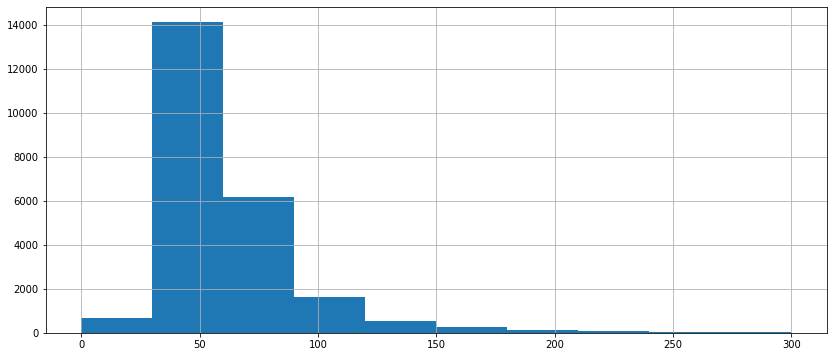

In [21]:
# Строим гистаграмму для столбца total_area
df['total_area'].hist(range=(0,300), figsize=(14,6));

Гистограмма сверху показывает количества квартир по `х-оси`, и общую площадь недвижимости по `у-оси`. Мы видим что примерно 90% всех недвижимостей имеет общую площадь между 30 м2 и 90 м2. Также очень мало квартир которые имеют меньше 30 м2, также мало квартир которые имеют общую площадь больше 100 м2.

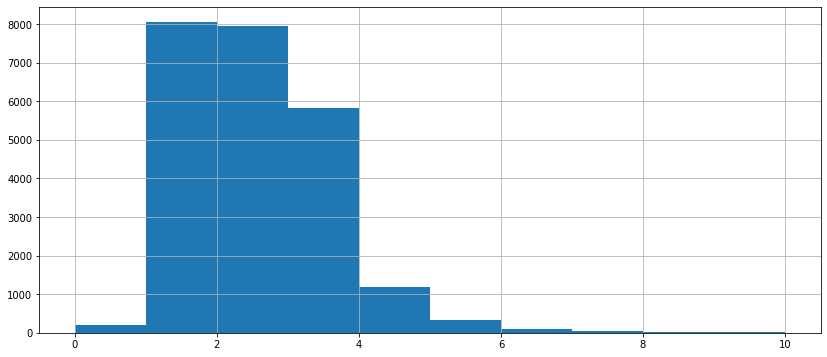

In [22]:
# Строим гистаграмму для столбца rooms
df['rooms'].hist(range=(0,10), figsize=(14,6));

График сверху показывает количество комнат в квартире по `х-оси` и количество квартир по `у-оси`. Больше 90% квартир имеют от 1 до 3 комнат. Мало квартир которые имеют больше 4 комнат.

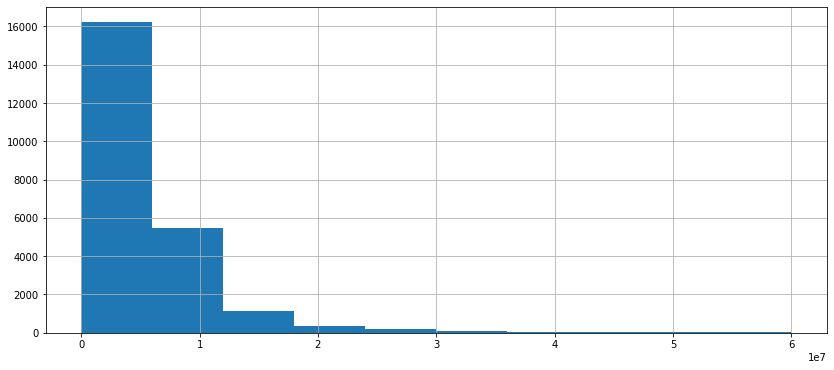

In [20]:
# Строим гистаграмму для столбца last_price
df['last_price'].hist(range=(0,60000000), figsize=(14,6));

Гистограмма показывает цены квартир по `х-оси` и количества квартир по `у-оси`. Больше 16,000 квартир имеют цены до `5,000,000 рублей`. 5,000 квартир имеют цену между `5,000,000 рублей` и `12,000,000 рублей`.

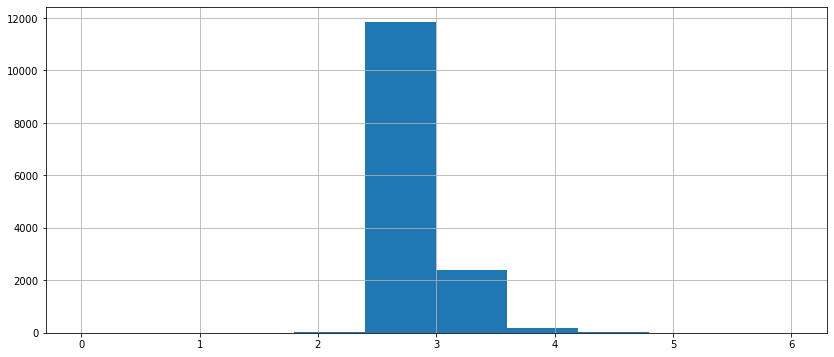

In [23]:
# Строим гистаграмму для столбца ceiling_height
df['ceiling_height'].hist(range=(0,6), figsize=(14,6));

Гистограмма показывает количество квартир по `у-оси` и высоту потолков `по х-оси`. Тут сразу видно, что почти 97-98% квартир имеют потолки с высотой от 2.5 метров и выше.

Изучим время продажи квартиры. Построем гистограмму. Посчитаем среднее и медиану. Ответим на такие вопросы как:
   - сколько обычно занимает продажа 
   - Когда можно считать, что продажи прошли очень быстро, а когда необычно долго?

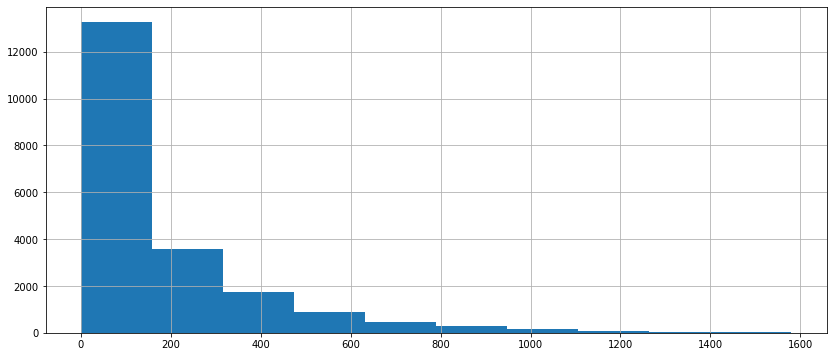

In [24]:
# Строим гистаграмму для столбца days_exposition
df['days_exposition'].hist(figsize=(14,6));

Гистограмма показывает количество квартир по `у-оси` и количество дней было размещено объявление (от публикации до снятия) по `х-оси`. Видно, что почти 60% квартир продаются до 180 дней.

In [25]:
# Выводим на экран стат данные по столбцу days_exposition
df.describe()['days_exposition']

count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

В среднем квартира продаётся в течение 180 дней, и это много дней, почти 6 месяцев. Медиана подсказывает что продажа квартир 95 дней, что более вероятно. Гистограмма показывает что более 12000 квартир продались между 1 и 180 днями, и это большое количество. Наверное будет правильнее если сделать срезы по комнатам или по площади квартир, это позволит увидеть картину точнее. Также имеются квартиры которые, продаются годами, а может и не продались вообще просто продавец устал продавать и снял объявление.

Уберем редкие и выбивающиеся значения. Опишем, какие особенности обнаружили.

In [26]:
# Выводим количество данных для каждой категории для столбца studio
df['studio'].value_counts()

False    23550
True       149
Name: studio, dtype: int64

Для столбца `studio` имеются только 149 значений со значением `True`, думаю можно удалить этот столбец.

In [27]:
# Выводим количество данных для каждой категории для столбца open_plan
df['open_plan'].value_counts()

False    23632
True        67
Name: open_plan, dtype: int64

Думаю можно удалить этот столбец так как имеются только 67 значений со значением `True`.

In [28]:
# Выводим количество данных для каждой категории для столбца is_apartment
df['is_apartment'].value_counts()

False    23649
True        50
Name: is_apartment, dtype: int64

Думаю можно удалить этот столбец так как имеются только 50 значений со значением `True`.

Какие факторы больше всего влияют на стоимость квартиры? 

Изучим, зависит ли цена от:

- площади, 
- числа комнат, 
- удалённости от центра. 

Также изучим зависимость цены от того, на каком этаже расположена квартира: 

- первом, 
- последнем, 
- другом. 

Еще изучим зависимость от даты размещения: 
- дня, 
- месяца, 
- года.

In [29]:
# Выводим на экран корреляций выбранных столбцов last_price, total_area, rooms, cityCenters_nearest между собой
interest_columns = ['last_price', 'total_area', 'rooms', 'cityCenters_nearest']
df[interest_columns].corr()

,last_price,total_area,rooms,cityCenters_nearest
last_price,1.000000,0.653675,0.363343,-0.206747
total_area,0.653675,1.000000,0.758344,-0.231446
rooms,0.363343,0.758344,1.000000,-0.184864
cityCenters_nearest,-0.206747,-0.231446,-0.184864,1.000000


Корреляция сверху показывает что площадь имеет умеренную позитивную корреляцию с ценой. Число комнат имеет слабую позитивную корреляцию. Удаленность от центра показывает негативную корреляцию.

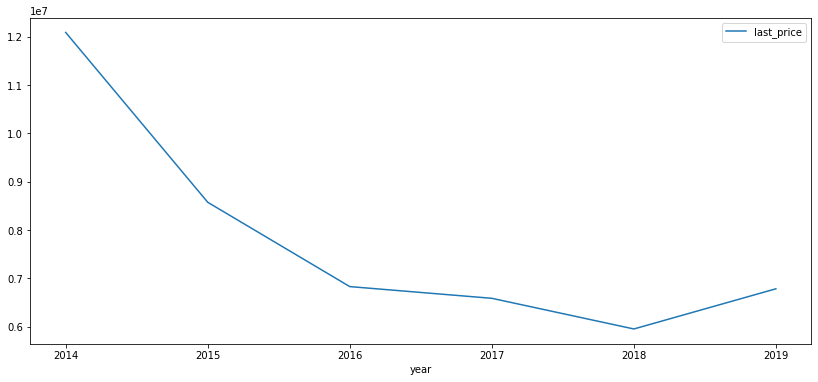

In [30]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df.pivot_table(values='last_price', index='year', aggfunc='mean').plot(figsize=(14,6));

Гистограмма показывает среднюю цену квартир (`у-оси`) погодично (`х-оси`). Данные показывает как в среднем менялось цена квартиры каждый год. За последние 6 лет средняя цена на недвижимость упала. 

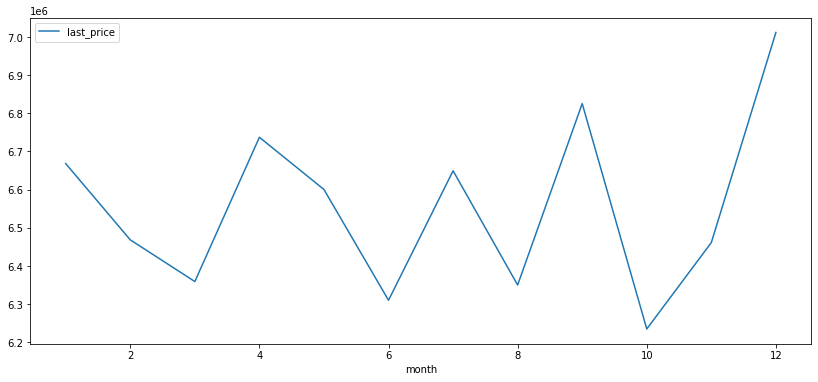

In [31]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df.pivot_table(values='last_price', index='month', aggfunc='mean').plot(figsize=(14,6));

График показывает как среднем меняется цена квартиры (`у-оси`) каждый месяц (`х-оси`). Пик цен на недвижимость достигается ближе к новому году, и еще можно увидеть сезонность изменение цен.

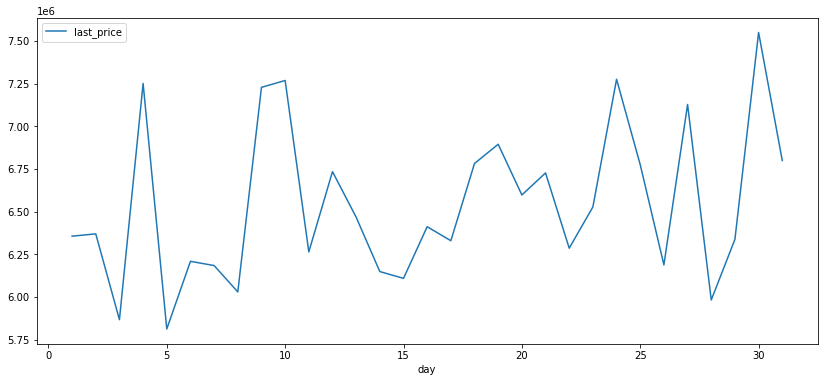

In [32]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df.pivot_table(values='last_price', index='day', aggfunc='mean').plot(figsize=(14,6));

График показывает как среднем менялось цена квартиры (`у-оси`) каждый день (`х-оси`). Очень волатильные данные получается если по дням смотреть.

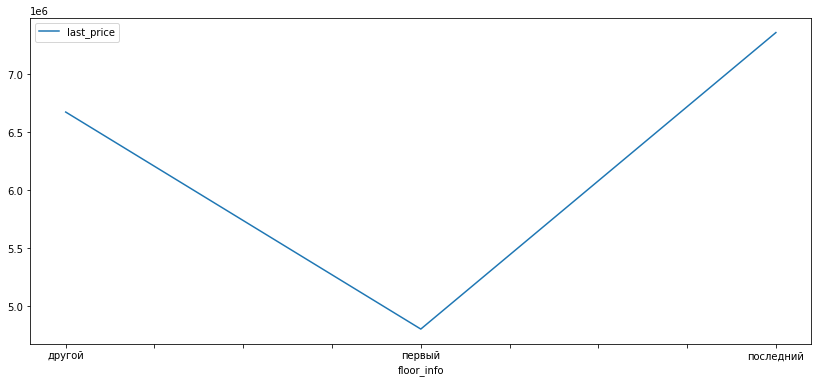

In [33]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df.pivot_table(values='last_price', index='floor_info', aggfunc='mean').plot(figsize=(14,6));

График показывает как среднем менялось цена квартиры (`у-оси`) относительно этажности (`х-оси`). Мы видим что цены квартир зависит от этажности: последние этажи стоят дороже чем первые этажи и другие этажи. Другие этажи стоят дороже чем первые этажи.

- Выберем 10 населённых пунктов с наибольшим числом объявлений. Посчитаем среднюю цену квадратного метра в этих населённых пунктах. Выделим населённые пункты с самой высокой и низкой стоимостью жилья. Эти данные можно найти по имени в столбце locality_name.

In [34]:
# Выберем 10 населённых пунктов с наибольшим числом объявлений
df['locality_name'].value_counts().head(10)

Санкт-Петербург      15721
посёлок Мурино         522
посёлок Шушары         440
Всеволожск             398
Пушкин                 369
Колпино                338
посёлок Парголово      327
Гатчина                307
деревня Кудрово        299
Выборг                 237
Name: locality_name, dtype: int64

66% всех объявлений являются из Санкт-Петербурга. Объявления из остальных местностей являются очень незначимыми числами.

In [35]:
# Посчитаем среднюю цену квадратного метра в этих населённых пунктах
df_ = df.pivot_table(index='locality_name', values='price_per_m2', aggfunc=['count', 'mean'])
df_.columns = ['count', 'mean']
df_.sort_values('count', ascending=False).head(10)

,count,mean
locality_name,,
Санкт-Петербург,15721,114849.008794
посёлок Мурино,522,85752.189195
посёлок Шушары,440,78677.364217
Всеволожск,398,68654.473986
Пушкин,369,103125.819291
Колпино,338,75424.579098
посёлок Парголово,327,90175.913458
Гатчина,307,68746.146763
деревня Кудрово,299,92473.547576


In [36]:
# Выделим населённые пункты с самой высокой стоимостью жилья
max_price = df_.sort_values('mean', ascending=False).head(10)
max_price

,count,mean
locality_name,,
посёлок Лисий Нос,2,121616.221359
Зеленогорск,24,115122.799198
Санкт-Петербург,15721,114849.008794
посёлок Репино,4,104238.614786
Пушкин,369,103125.819291
Сестрорецк,183,101757.616875
Кудрово,173,100253.043304
деревня Мистолово,11,98549.976709
посёлок Левашово,1,96997.690531


Самая дорогая цена за квадратный метр в посёлке Лисий Нос. Санкт-Петербург входит в тройку. Но для посёлка Лисий Нос и Зеленогорск данных мало.

In [37]:
# Выделим населённые пункты с самой низкой стоимостью жилья
min_price = df_.sort_values('mean', ascending=True).head(10)
min_price

,count,mean
locality_name,,
деревня Старополье,3,11206.221198
посёлок станции Свирь,2,11481.481481
деревня Вахнова Кара,1,11688.311688
деревня Выскатка,2,12335.480902
поселок Совхозный,2,12629.129129
деревня Малая Романовка,1,12724.550898
поселок Тёсово-4,1,12931.034483
деревня Сижно,1,13709.677419
деревня Ям-Тесово,2,13711.553373


В деревне Старополье самая низкая стоимость жилья за м2 со стоимостью 11206.22. В топ 3 также входят посёлок станции Свирь со стоимостью жилья в 11481.48 за м2, также деревня Вахнова Кара со стоимостью жилья в 11688.31 за м2.

* Изучим предложения квартир: 

    * для каждой квартиры есть информация о расстоянии до центра
    * Выделим квартиры в Санкт-Петербурге (locality_name)
    * Выясним, какая область входит в центр 
    * Создадим столбец с расстоянием до центра в километрах: округлим до целых значений 
    * Посчитаем среднюю цену для каждого километра
    * Построем график, который показывает, как цена зависит от удалённости от центра
    * Определим границу, где график сильно меняется, — это и будет центральная зона

In [38]:
# Выделим квартиры в Санкт-Петербурге (locality_name)
df_spg = df.query('locality_name=="Санкт-Петербург"').reset_index()

In [39]:
# Создадим столбец с расстоянием до центра в километрах: округлим до целых значений
cityCenters_nearest_km = (df_spg['cityCenters_nearest'] / 1000).round(decimals=0)
df_spg['cityCenters_nearest_km'] = cityCenters_nearest_km

In [40]:
# Выводим на жкран первые 5 строк 
df_spg.head(5)

,index,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,...,ponds_nearest,days_exposition,price_per_m2,day,month,year,floor_info,living_total_ratio,kitchen_total_ratio,cityCenters_nearest_km
0,0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,...,755.0,NaN,120370.370370,7,3,2019,другой,0.472222,0.231481,16.0
1,2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,...,574.0,558.0,92785.714286,20,8,2015,другой,0.612500,0.148214,14.0
2,3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,...,234.0,424.0,408176.100629,24,7,2015,другой,NaN,NaN,7.0
3,4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,...,48.0,121.0,100000.000000,19,6,2018,другой,0.320000,0.410000,8.0
4,7,5,7915000.0,71.6,2019-04-18,2,NaN,24.0,NaN,22,...,NaN,NaN,110544.692737,18,4,2019,другой,NaN,0.263966,12.0


In [41]:
#  Посчитаем среднюю цену для каждого километра
price_per_center_km = df_spg['last_price'].mean() / df_spg['cityCenters_nearest_km']
df_spg['price_per_center_km'] = price_per_center_km

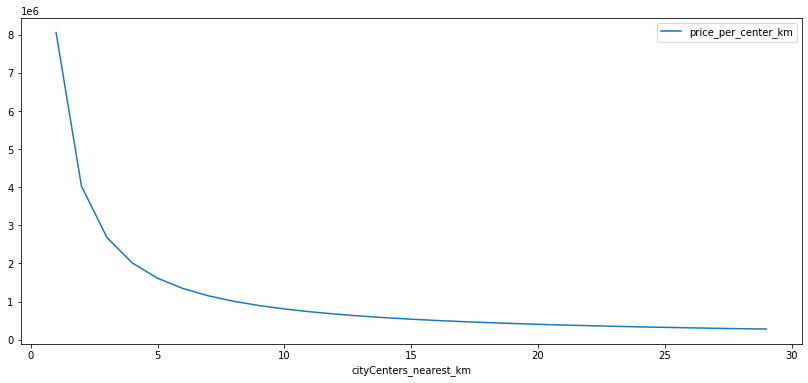

In [42]:
# Построем график, который показывает, как цена зависит от удалённости от центра
df_spg.pivot_table(values='price_per_center_km', index='cityCenters_nearest_km', aggfunc='mean').plot(figsize=(14, 6));

График показывает как среднем меняется цена квартиры (`у-оси`) относительно расстояния до центра города (`х-оси`). График показывает, как цена зависит от удалённости от центра в городе Санкт-Петербург. Определим границу, где график сильно меняется, — это и будет центральная зона, следовательно граница центральной зоны является 5 км, так как сильно изменилась цена от 8 миллионов до 1.6 миллионов. После 5 км цены не сильно меняются.

* Выделим сегмент квартир в центре и проанализируем эту территорию

* Изучим следующие параметры: 
    - площадь 
    - цена 
    - число комнат 
    - высота потолков 

* Также выделим факторы, которые влияют на стоимость квартиры 
    - число комнат 
    - этаж 
    - удалённость от центра 
    - дата размещения объявления

In [43]:
# Проанализируем эту территорию
df_spg_center = df_spg.query('cityCenters_nearest_km==5')

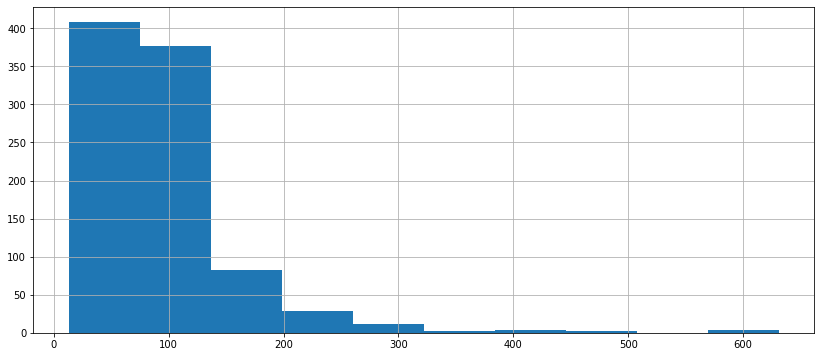

In [44]:
# площадь гистограмма в данных Санкт-Петербурга
df_spg_center['total_area'].hist(figsize=(14,6));

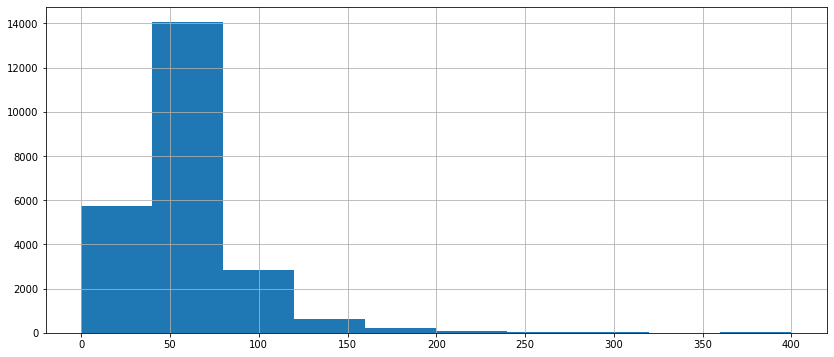

In [45]:
# гисторамма площадь во всех данных
df['total_area'].hist(range=(0, 400), figsize=(14,6));

Гистограмма показывает по `у-оси` количество квартир и по `х-оси` площадь квартиры в квадратных метрах (м²). Дистрибуция данных между двумя гистограммами разное. Основное количество данных:
- для всей выборки находятся до 120 м²
- для Санкт-Петербурга это значение до 200 м²

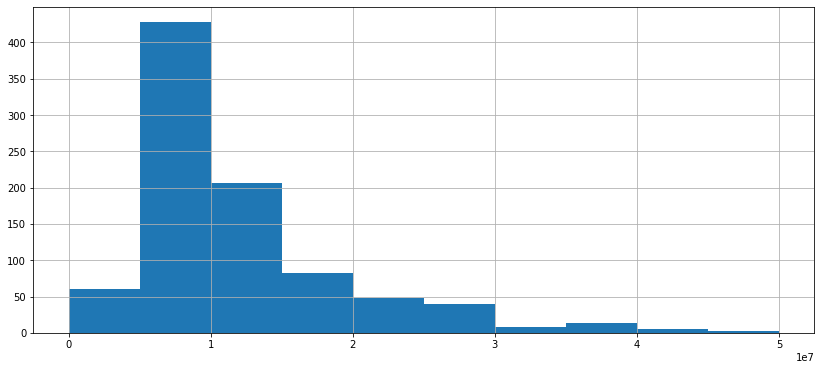

In [46]:
# цена квартир гистограмма в данных Санкт-Петербурга
df_spg_center['last_price'].hist(range=(0, 50000000), figsize=(14, 6));

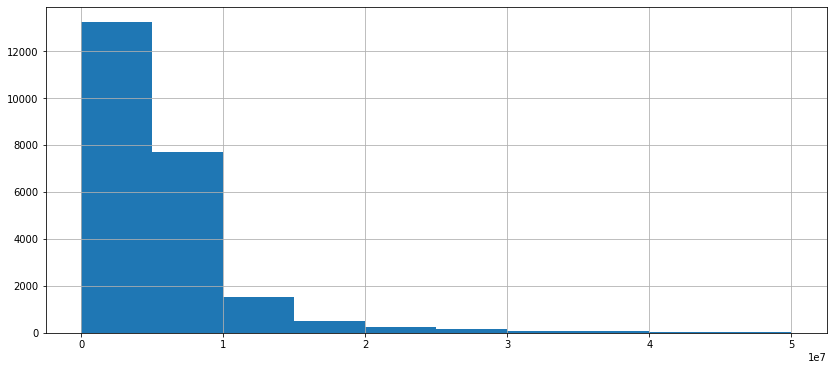

In [47]:
# цена гистограмма во всех данных
df['last_price'].hist(range=(0, 50000000), figsize=(14,6));

Гистограмма показывает по `у-оси` количество квартир и по `х-оси` цена квартиры. Дистрибуция данных между двумя гистограммами разная. 
- для Санкт-Петербурга 50% данных находятся в первом бине, то есть до 10,000,000
- для всех данных, 90% данных находятся в первом бине, то есть до 20,000,000

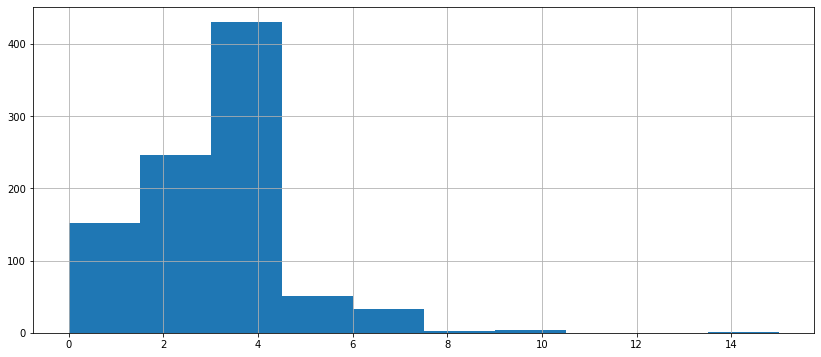

In [48]:
# количество комнат гистограмма в данных Санкт-Петербурга
df_spg_center['rooms'].hist(figsize=(14,6));

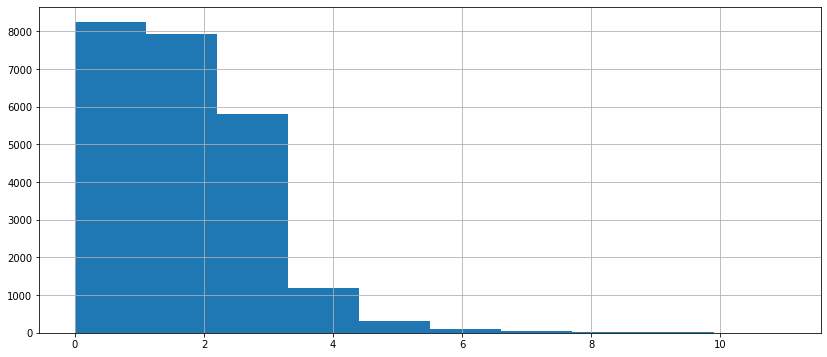

In [49]:
# количество комнат гистограмма во всех данных
df['rooms'].hist(range=(0, 11), figsize=(14,6));

Гистограмма показывает по `у-оси` количество квартир и по `х-оси` количество комнат. Дистрибуция данных между двумя гистограммами разная. 
- для Санкт-Петербурга 85% данных находятся от 0 до 4 комнат
- для всей выборки 90% данных располагаются от 0 до 3 комнат

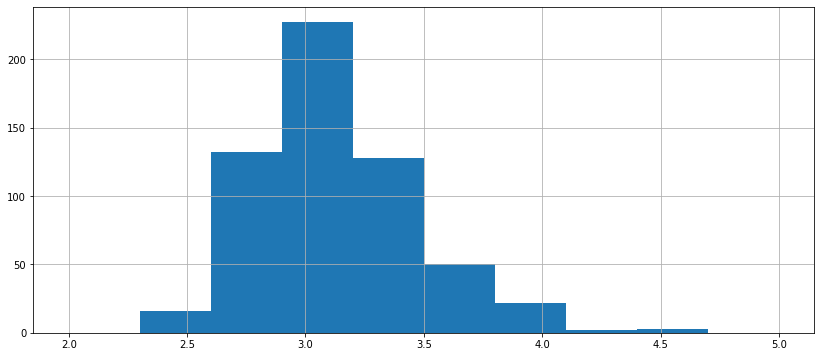

In [50]:
# высота потолков гистограмма в данных Санкт-Петербурга
df_spg_center['ceiling_height'].hist(range=(2, 5), figsize=(14,6));

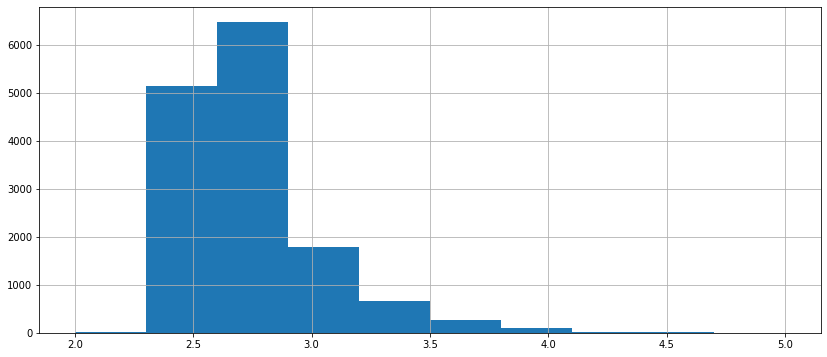

In [51]:
# высота потолков гистограмма во всех данных
df['ceiling_height'].hist(range=(2, 5), figsize=(14,6));

Гистограмма показывает по `у-оси` количество квартир и по `х-оси` высоту потолков. Дистрибуция данных:
- для Санкт-Петербурга дистрибуция похожа на нормальное распределение, 90% данных находятся между 2.7 и 3.7 м
- для всей выборки дистрибуция похожа на распределение Пуассона, 95% между 2.3 и 3.3 м

In [52]:
# Выделим факторы, которые влияют на стоимость квартиры 
# количество комнат, этаж, удалённость от центра, дата размещения объявления
interest_columns = ['last_price', 'rooms', 'cityCenters_nearest', 'days_exposition']
df_spg_center[interest_columns].corr()

,last_price,rooms,cityCenters_nearest,days_exposition
last_price,1.000000,0.377472,-0.002063,0.057005
rooms,0.377472,1.000000,-0.079628,0.050107
cityCenters_nearest,-0.002063,-0.079628,1.000000,0.054294
days_exposition,0.057005,0.050107,0.054294,1.000000


Для данных Санкт-Петербурга, имеется слабая корреляция между стоимостью квартиры и количество комнат со значением 0.37. Удалённость от центра и дата размещения объявления не коррелирует с ценой на недвижимость.

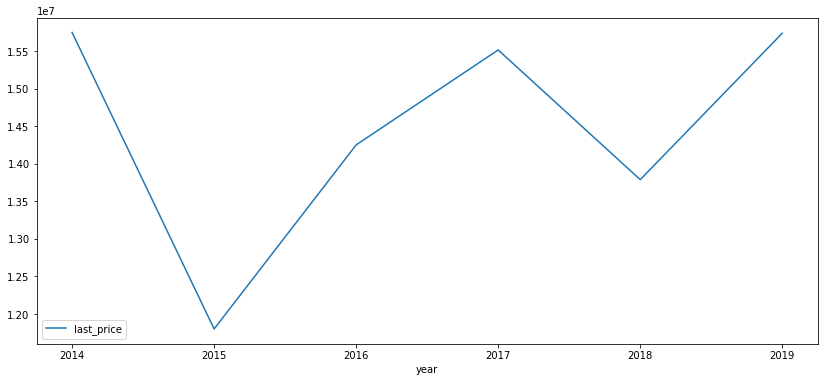

In [53]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df_spg_center.pivot_table(values='last_price', index='year', aggfunc='mean').plot(figsize=(14, 6));

График показывает как среднем менялось цена квартиры `(у-оси)` каждый год  `(х-оси)`. Последние 6 лет средняя цена на недвижимость не изменилась в городе Санкт-Петербург, но имелись спады и подъемы.

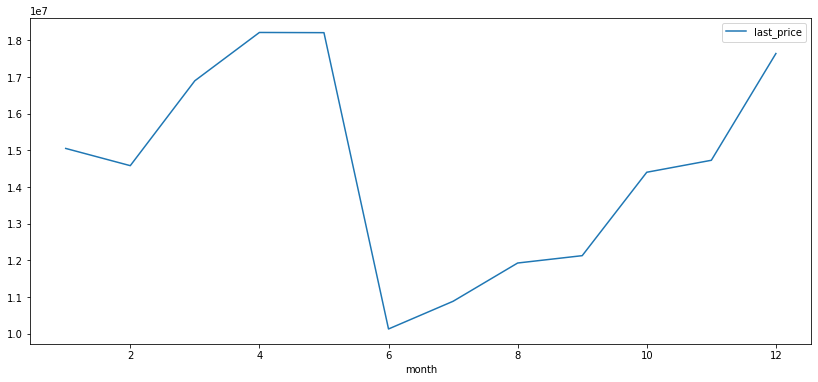

In [54]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df_spg_center.pivot_table(values='last_price', index='month', aggfunc='mean').plot(figsize=(14, 6));

График показывает как среднем меняется цена квартиры по `y-оси` каждый месяц по `x-оси` в городе Санкт-Петербург. Пик цен на недвижимость достигается в мае и ближе к новому году. Спад цен происходит в июне, и идёт на подъём до декабря. 

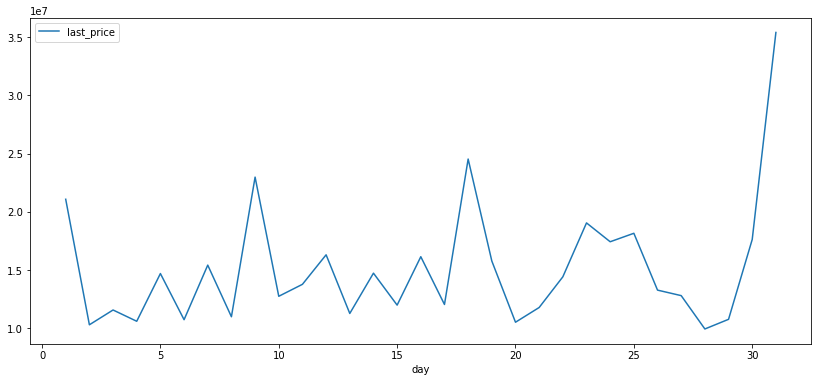

In [55]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df_spg_center.pivot_table(values='last_price', index='day', aggfunc='mean').plot(figsize=(14, 6));

График показывает как среднем менялось цена квартиры по `y-оси` каждый день по `x-оси` в городе Санкт-Петербург. Поведение графика очень волатильна, также к концу месяца цены достигают своё пиковое значение.

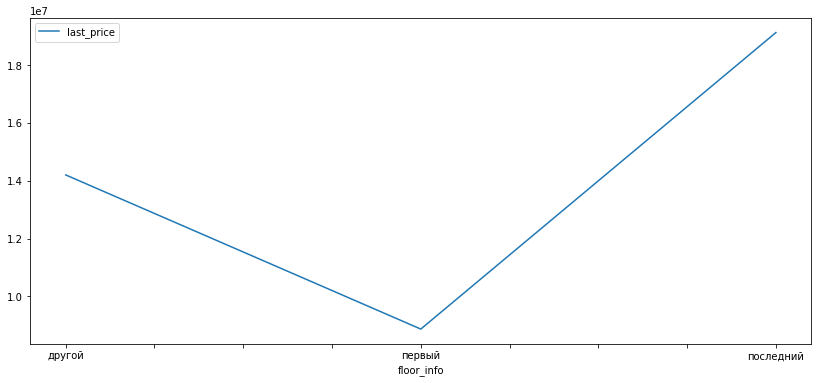

In [56]:
# Строим pivot table, после этого вызоваем фукнцию plot() для построения графика
df_spg_center.pivot_table(values='last_price', index='floor_info', aggfunc='mean').plot(figsize=(14, 6));

Цены квартир зависит от этажности: последние этажи стоят дороже чем первые этажи и другие этажи. Другие этажи стоят дороже чем первые этажи.

## Общий вывод

- В этом проекте были определены пропущенные значения и заполнены пропущенные значения со средним значением. 
- Также были изменены типы данных для некоторых столбцов. 
- Было посчитано цена квадратного метра, этаж квартиры (первый, последний, другой), соотношение жилой и общей площади.
- Посчитано корреляция между этими параметрами площадь, цена, число комнат, высота потолков, чтобы определить есть ли взаимосвязь между параметрами. 
- Также были построены гистограммы для каждого вышеуказанного параметра.


- ДЛЯ ВСЕХ ДАННЫХ
    - Статиска показывает что цена недвижимости, столбец `last_price`, варьируется между `12,190 рублей` и `763,000,000 рублей`. Также среднее значение и медиана, для столбца `last_price` не сильно отличаются друг от друга, `6,541,549 рублей` и  `4,650,000 рублей` соответственно.

    - Общая площадь, столбец `total_area`, также нуждается во внимании, так как наблюдаются сильное различия в стат данных. Например, минимальная площадь `12 м2`, а максимальная площадь `900 м2`, разница существенная. Среднее значение и медиана, для столбца `total_area` не сильно отличаются друг от друга, `60.34 м2` и `52 м2`. 

    - В среднем квартира продаётся в течение 180 дней, и это много дней, почти 6 месяцев. Медиана подсказывает что продажа квартир 95 дней, что более вероятно. Гистограмма показывает что более 12000 квартир продались между 1 и 180 днями, и это большое количество. Наверное будет правильнее если сделать срезы по комнатам или по площади квартир, это позволит увидеть картину точнее. Также имеются квартиры которые, продаются годами, а может и не продались вообще просто продавец устал продавать и снял объявление.

    - Следующий важный параметр цена за квадратный метер, `price_per_m2	`. Среднее и медиана близко расположены друг другу. Минимум и максимум значения очень далеки друг от друга, `99,422 рублей за м2` и `1,907,500 рублей за м2`.
        
     - 90% всех недвижимостей имеет общую площадь между 30 м2 и 90 м2. Также очень мало квартир которые имеют меньше 30 м2, также мало квартир которые имеют общую площадь больше чем 100 м2.    
     
    - Больше 16,000 квартир имеют цены до `5,000,000 рублей`. 5,000 квартир имеют цену между `5,000,000 рублей` и `12,000,000 рублей`.

    - 97-98% квартир имеют потолки с высотой от 2.5 метров и выше.    

    - Корреляция показывает что площадь имеет умеренную позитивную корреляцию с ценой. Число комнат имеет слабую позитивную корреляцию с ценой. Удаленность от центра показывает негативную корреляцию с ценой.
       
    - Самая дорогая цена за квадратный метр в посёлке Лисий Нос. Санкт-Петербург входит в тройку. Но для посёлка Лисий Нос и Зеленогорск данных мало.  
    
    - Санкт-Петербург является населённым пунктом с наибольшим числом объявлений.
        
    - В деревне Старополье самая низкая стоимость жилья за м2 со стоимостью 11206.22. В топ 3 также входят посёлок станции Свирь со стоимостью жилья в 11481.48 за м2, также деревня Вахнова Кара со стоимостью жилья в 11688.31 за м2.
     
    - Был выбран один город - Санкт-Петербург. На этих данных был построен график который показывает, как цена зависит от удалённости от центра. Граница центральной зоны является 5 км, так как в этой точке цены сильно изменились от 8 миллионов до 1.6 миллионов. После 5 км цены не сильно меняются.


- ПЛОЩАДЬ

    - Дистрибуция данных (количество квартир и по площадь квартиры в квадратных метрах (м²)) между двумя гистограммами разное. Основное количество данных:
    
        - для всей выборки находятся до 120 м²
        - для Санкт-Петербурга это значение до 200 м²


- ЦЕНА

    - Дистрибуция данных (количество квартир и цена квартиры) между двумя гистограммами разная.

        - для Санкт-Петербурга 50% данных находятся в первом бине, то есть до 10,000,000
        - для всех данных, 90% данных находятся в первом бине, то есть до 20,000,000


- КОЛИЧЕСТВО КОМНАТ

    - Дистрибуция данных (количество квартир и количество комнат) между двумя гистограммами разная. 
        
        - для Санкт-Петербурга 85% данных находятся от 0 до 4 комнат
        - для всей выборки 90% данных располагаются от 0 до 3 комнат


- ВЫСОТА ПОТОЛКОВ

    - Дистрибуция данных (количество квартир и высота потолков.) между двумя гистограммами разная:

        - для Санкт-Петербурга дистрибуция похожа на нормальное распределение, 90% данных находятся между 2.7 и 3.7 м
        - для всей выборки дистрибуция похожа на распределение Пуассона, 95% между 2.3 и 3.3 м


- Для Санкт-Петербурга

    - Имеется слабая корреляция между стоимостью квартиры и количество комнат со значением 0.37. Удалённость от центра и дата размещения объявления не коррелирует с ценой на недвижимость.
    
    - Последние 6 лет средняя цена на недвижимость не изменилась в городе Санкт-Петербург, но имелись спады и подъемы.
    
    - Пик цен на недвижимость достигается в мае и ближе к новому году. Спад цен происходит в июне, и идёт на подъём до декабря.
    
    - Поведение графика очень волатильна, также к концу месяца цены достигают своё пиковое значение.
    
    - Цены квартир зависит от этажности: последние этажи стоят дороже чем первые этажи и другие этажи. Другие этажи стоят дороже чем первые этажи.


- Между выборкой Санкт-Петербурга и со всей выборкой есть сходства, но большей части различий много. Например, различия в распределений данных в гистограммах, а сходство в как меняется цена относительно дня и этажности. 